#### Load cached data for route segmentation
#### No database connection needed - reusing the parquet file saved during Day 3.
#### Goal: group the 1,274 routes into meaningful clusters (e.g. "monopoly
#### high-fare," "contested high-volume") using K-Means, same technique as the
#### beverage project's vendor tiering.

In [1]:
import pandas as pd

gold_df = pd.read_parquet(r"..\data\processed\route_competitive_performance.parquet")
print(gold_df.shape)
print(gold_df.columns.tolist())
print(gold_df.describe())

(1274, 11)
['origin', 'dest', 'total_flights', 'avg_arr_delay', 'cancellations', 'avg_distance', 'avg_fare_lg', 'avg_large_ms', 'avg_fare_low', 'avg_lf_ms', 'total_passengers']
       total_flights  avg_arr_delay  cancellations  avg_distance  avg_fare_lg  \
count    1274.000000    1274.000000    1274.000000   1274.000000  1274.000000   
mean     1572.804553       7.386388      23.304553   1007.313187   240.050259   
std      1621.775320      10.591731      28.376022    593.840608    77.308080   
min         1.000000     -46.000000       0.000000    143.000000    58.000000   
25%       413.500000       2.090857       4.000000    566.000000   193.247500   
50%      1059.000000       6.565043      13.500000    901.000000   229.330000   
75%      2144.500000      11.702544      31.000000   1257.500000   282.100000   
max     11526.000000     194.000000     226.000000   2724.000000   626.230000   

       avg_large_ms  avg_fare_low    avg_lf_ms  total_passengers  
count   1274.000000   1274

#### Check for extreme outlier routes, then scale features for clustering
#### Flagging routes with unusually low flight counts before clustering, since a
#### route with just 1-2 flights all year isn't meaningfully comparable to a
#### real, established route. Then scaling all features so no single column
#### (like total_flights, which ranges into the thousands) dominates the
#### clustering just because of its raw size.

In [2]:
from sklearn.preprocessing import StandardScaler

# Check how many routes have very low flight counts
print("Routes with fewer than 20 flights in the year:", (gold_df['total_flights'] < 20).sum())
print("Routes with 0 passengers recorded:", (gold_df['total_passengers'] == 0).sum())

# Drop routes that are too thin to meaningfully cluster
clustering_df = gold_df[gold_df['total_flights'] >= 20].copy()
print(f"\nRoutes remaining after filtering: {len(clustering_df)} (dropped {len(gold_df) - len(clustering_df)})")

# Select the features that actually describe commercial character
features = ['avg_fare_lg', 'avg_large_ms', 'total_passengers', 'avg_arr_delay']
X = clustering_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled feature ranges (should all be roughly centered around 0):")
print(pd.DataFrame(X_scaled, columns=features).describe().loc[['mean', 'std', 'min', 'max']])

Routes with fewer than 20 flights in the year: 40
Routes with 0 passengers recorded: 3

Routes remaining after filtering: 1234 (dropped 40)

Scaled feature ranges (should all be roughly centered around 0):
       avg_fare_lg  avg_large_ms  total_passengers  avg_arr_delay
mean  4.894338e-16  2.188057e-16     -8.061263e-17  -1.036448e-16
std   1.000405e+00  1.000405e+00      1.000405e+00   1.000405e+00
min  -2.205468e+00 -2.426912e+00     -8.703674e-01  -2.817692e+00
max   4.988078e+00  1.269718e+00      7.196170e+00   8.559687e+00


#### Find the right number of clusters, then run K-Means
#### Testing k=2 through k=8 and looking at how much each additional cluster
#### actually improves the grouping (the "elbow method") - this justifies the
#### final choice of k rather than picking an arbitrary number.

In [3]:
from sklearn.cluster import KMeans

inertia_values = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

for k, inertia in zip(k_range, inertia_values):
    print(f"k={k}: inertia={inertia:.1f}")

C:\Users\HARDEEP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HARDEEP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HARDEEP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HARDEEP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

k=2: inertia=3667.5
k=3: inertia=3023.5
k=4: inertia=2476.3
k=5: inertia=2108.1
k=6: inertia=1944.4
k=7: inertia=1799.6
k=8: inertia=1689.7


C:\Users\HARDEEP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


#### Elbow method + silhouette score together
#### Inertia alone always improves with more clusters, so it can't tell us when
#### we've gone too far. Silhouette score measures both cluster tightness and
#### separation, and its peak value is a stronger, more defensible signal for
#### choosing k.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values = []
silhouette_values = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

print(f"{'k':>3} {'inertia':>12} {'silhouette':>12}")
for k, inertia, sil in zip(k_range, inertia_values, silhouette_values):
    print(f"{k:>3} {inertia:>12.1f} {sil:>12.4f}")

C:\Users\HARDEEP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HARDEEP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HARDEEP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\HARDEEP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

  k      inertia   silhouette
  2       3667.5       0.2699
  3       3023.5       0.2710
  4       2476.3       0.2865
  5       2108.1       0.2961
  6       1944.4       0.2929
  7       1799.6       0.2306
  8       1689.7       0.2126


#### Run K-Means with k=5 and profile each cluster
#### Both inertia and silhouette score point to 5 clusters as the right choice.
#### Fitting the final model and then looking at what each cluster actually
#### represents commercially - not just cluster numbers, but real labels like
#### "monopoly high-fare" or "contested high-volume."

In [5]:
final_model = KMeans(n_clusters=5, random_state=42, n_init=10)
clustering_df['cluster'] = final_model.fit_predict(X_scaled)

cluster_profile = clustering_df.groupby('cluster')[features].mean()
cluster_profile['route_count'] = clustering_df.groupby('cluster').size()

print(cluster_profile.round(2))

         avg_fare_lg  avg_large_ms  total_passengers  avg_arr_delay  \
cluster                                                               
0             198.80          0.56            548.11           6.36   
1             290.62          0.77            341.19          19.36   
2             202.55          0.95            284.75           4.36   
3             344.93          0.60            564.45           3.76   
4             257.36          0.52           2270.19           9.31   

         route_count  
cluster               
0                320  
1                177  
2                446  
3                181  
4                110  


C:\Users\HARDEEP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


#### Add cluster names and save the labeled dataset
#### Attaching readable business names to each cluster number, then saving the
#### final labeled table so it's ready for the portfolio write-up and any later
#### dashboard work, without needing to re-run the clustering.

In [6]:
cluster_names = {
    0: "Balanced Competitive",
    1: "Premium Dominant, Service-Strained",
    2: "Niche Monopoly Routes",
    3: "Premium High-Demand",
    4: "Major Hub Competitive Routes"
}

clustering_df['cluster_name'] = clustering_df['cluster'].map(cluster_names)

clustering_df.to_parquet(r"..\data\processed\route_clusters.parquet")

print(clustering_df[['origin', 'dest', 'cluster_name']].sample(10))
print("\nsaved to data/processed/route_clusters.parquet")

     origin dest                        cluster_name
1023    MDW  SDF               Niche Monopoly Routes
1261    PHX  TUL                Balanced Competitive
312     DFW  FLL  Premium Dominant, Service-Strained
824     DAL  PHL  Premium Dominant, Service-Strained
787     MIA  ORF  Premium Dominant, Service-Strained
1053    CLT  SFO  Premium Dominant, Service-Strained
785     LGA  ORF                Balanced Competitive
594     IAH  MAF               Niche Monopoly Routes
1110    PSP  SJC               Niche Monopoly Routes
604     CMH  MCO                Balanced Competitive

saved to data/processed/route_clusters.parquet


#### Visualize the clusters to sanity-check the numbers
#### Numbers in a table can look convincing even if the clusters don't actually
#### separate well. Plotting fare vs. market share, and passengers vs. delay,
#### colored by cluster, to visually confirm the groups make sense - not just
#### trust the averages.

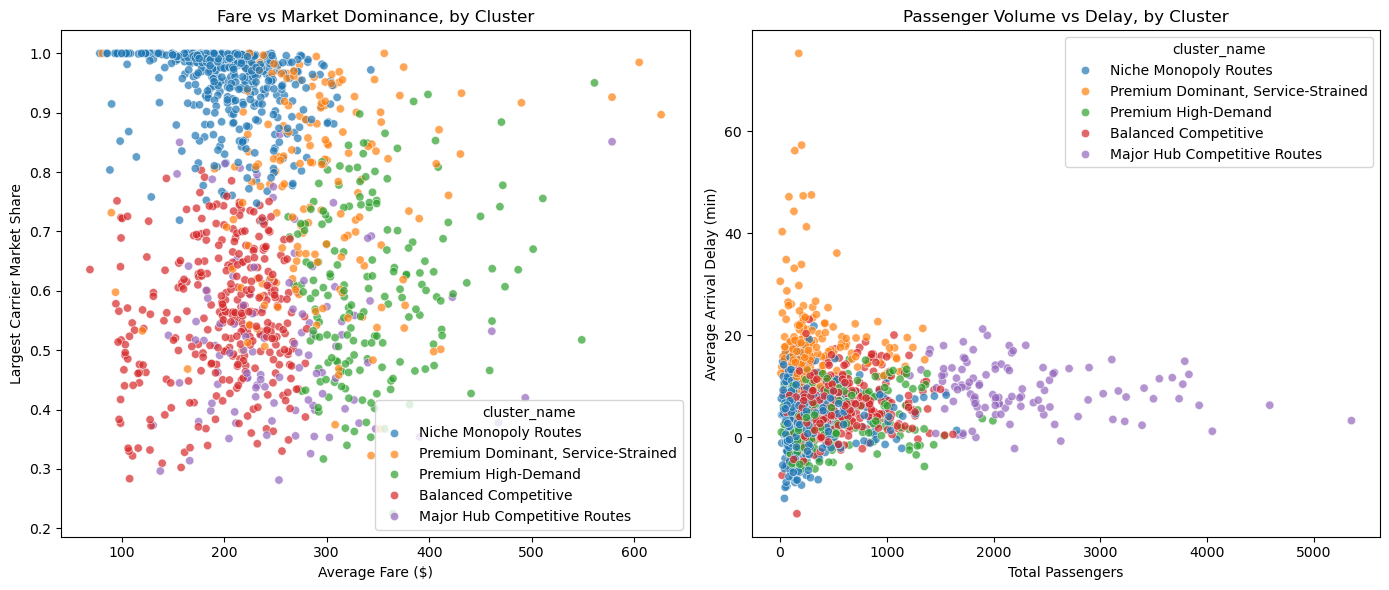

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs(r"..\reports\figures", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=clustering_df, x='avg_fare_lg', y='avg_large_ms',
    hue='cluster_name', palette='tab10', alpha=0.7, ax=axes[0]
)
axes[0].set_title('Fare vs Market Dominance, by Cluster')
axes[0].set_xlabel('Average Fare ($)')
axes[0].set_ylabel('Largest Carrier Market Share')

sns.scatterplot(
    data=clustering_df, x='total_passengers', y='avg_arr_delay',
    hue='cluster_name', palette='tab10', alpha=0.7, ax=axes[1]
)
axes[1].set_title('Passenger Volume vs Delay, by Cluster')
axes[1].set_xlabel('Total Passengers')
axes[1].set_ylabel('Average Arrival Delay (min)')

plt.tight_layout()
plt.savefig(r"..\reports\figures\route_clusters.png", dpi=150)
plt.show()

#### Use PCA to properly visualize the 4D clustering in 2D
#### The earlier plots only showed 2 of the 4 features at a time, so clusters
#### separated across all 4 dimensions can look scattered when viewed through
#### just 2. PCA compresses all 4 features into 2 new dimensions chosen
#### specifically to preserve the real separation between groups.

These 2 PCA dimensions explain 64.4% of the total variation in the original 4 features


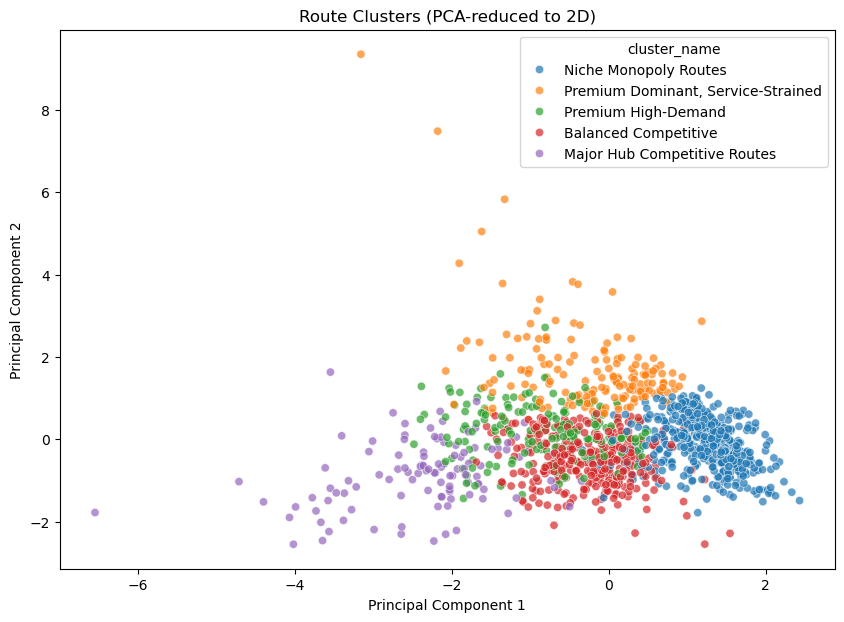

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

clustering_df['pca_1'] = pca_result[:, 0]
clustering_df['pca_2'] = pca_result[:, 1]

print(f"These 2 PCA dimensions explain {pca.explained_variance_ratio_.sum()*100:.1f}% of the total variation in the original 4 features")

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=clustering_df, x='pca_1', y='pca_2',
    hue='cluster_name', palette='tab10', alpha=0.7
)
plt.title('Route Clusters (PCA-reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig(r"..\reports\figures\route_clusters_pca.png", dpi=150)
plt.show()